# 02. Perceptrón Multicapa Inicial

## 1. Introducción

Teniendo ya un baseline histórico (la ecuación anaítica ya creada que describe
la física del problema), y un baseline desde una perspectiva de aprendizaje
automático, se procede a crear una primera red neuronal. No se realiza
directamente la red neuronal principal porque así se permite encapsular y tratar
el proyecto como objetivos seccionados que permiten mayor orden, mayor
entendimiento, y mayor escalabilidad.

## 2. Implementación

Para ello, primero se importan los módulos necesarios para realizar el objetivo
de esta libreta.

In [15]:
# Primeramente se recarga el paquete src
%load_ext autoreload
%autoreload 2

# Después se importan los paquetes externos necesarios
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import optuna
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Y por último se importan los módulos internos del paquete src
from src.dataset.dataset import RadiationDataset, subset_to_numpy
from src.learning.models import MLPInicial

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Después se preprocesa el dataset para que sea usado por la MLP.

In [6]:
# Se carga el dataset
dataset = RadiationDataset('../data/df_plotter_cm2.csv')

# Se dividen los datos en train, validation y test sets
train_set, val_set, test_set = dataset.data_split(test_factor=0.2,
                                                  val_factor=0.2,)

# Se crea un preprocesador para normalizar los datos
preprocessor = StandardScaler()
# Se preprocesan los datos
dataset.preprocess(train_set=train_set, preprocessor=preprocessor)

# Usamos tu función para separar features y target
X_train_np, y_train_np = subset_to_numpy(train_set)
X_val_np, y_val_np = subset_to_numpy(val_set)
# Convertimos los arrays de numpy a tensores de PyTorch
X_train_tensor = torch.tensor(X_train_np, dtype=torch.float32)
# Hacemos .view(-1, 1) para que el target tenga la misma forma [N, 1] que la salida de la red
y_train_tensor = torch.tensor(y_train_np, dtype=torch.float32).view(-1, 1) 

X_val_tensor = torch.tensor(X_val_np, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_np, dtype=torch.float32).view(-1, 1)

# Obtenemos la dimensión de entrada dinámicamente
input_dim = X_train_tensor.shape[1]

Se crea el perceptrón multicapa y se buscan los mejores parámetros utilizando optuna

In [13]:
def objective(trial):
    # 1. Sugerir hiperparámetros
    hidden_dim = trial.suggest_int('hidden_dim', 16, 128)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    
    # 2. Instanciar el modelo (usando input_dim del dataset)
    # Suponiendo que X_train_tensor ya está definido
    input_dim = X_train_tensor.shape[1] 
    model = MLPInicial(input_dim=input_dim, hidden_dim=hidden_dim)
    
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    # 3. Bucle de entrenamiento simplificado
    model.train()
    for epoch in range(50): # Ajusta las épocas según necesites
        optimizer.zero_grad()
        outputs = model(X_train_tensor)
        loss = criterion(outputs, y_train_tensor)
        loss.backward()
        optimizer.step()
        
        # Opcional: Reportar progreso para 'pruning'
        # trial.report(loss.item(), epoch)
        # if trial.should_prune(): raise optuna.exceptions.TrialPruned()

    # 4. Evaluación con el conjunto de validación
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
    
    return val_loss.item()

# Queremos minimizar el Error Cuadrático Medio (MSE)
study = optuna.create_study(direction='minimize', study_name="MLP_Inicial")

# Ejecutamos 50 intentos (trials)
study.optimize(objective, n_trials=50)

# Mostramos los resultados finales
print("\n--- Resultados Optuna ---")
print(f"Mejor MSE en validación: {study.best_value:.4f}")
print(f"Mejores hiperparámetros: {study.best_params}")

[I 2026-02-23 18:33:43,193] A new study created in memory with name: MLP_Inicial


[I 2026-02-23 18:33:43,238] Trial 0 finished with value: 0.5053557753562927 and parameters: {'hidden_dim': 56, 'lr': 0.00039594596101879306}. Best is trial 0 with value: 0.5053557753562927.
[I 2026-02-23 18:33:43,325] Trial 1 finished with value: 0.24486182630062103 and parameters: {'hidden_dim': 78, 'lr': 0.0005222792546207104}. Best is trial 1 with value: 0.24486182630062103.
[I 2026-02-23 18:33:43,393] Trial 2 finished with value: 0.514746904373169 and parameters: {'hidden_dim': 65, 'lr': 0.000219579819044663}. Best is trial 1 with value: 0.24486182630062103.
[I 2026-02-23 18:33:43,468] Trial 3 finished with value: 0.596868634223938 and parameters: {'hidden_dim': 26, 'lr': 0.0004694054322120722}. Best is trial 1 with value: 0.24486182630062103.
[I 2026-02-23 18:33:43,509] Trial 4 finished with value: 0.5894330739974976 and parameters: {'hidden_dim': 47, 'lr': 0.0003051639167292456}. Best is trial 1 with value: 0.24486182630062103.
[I 2026-02-23 18:33:43,564] Trial 5 finished with va


--- Resultados Optuna ---
Mejor MSE en validación: 0.1469
Mejores hiperparámetros: {'hidden_dim': 107, 'lr': 0.009777052029209933}


In [14]:
best_hidden_dim = study.best_params['hidden_dim']
best_lr = study.best_params['lr']

print(f"Entrenando modelo final con: hidden_dim={best_hidden_dim}, lr={best_lr:.6f}")

# --- 2. PREPARAR DATOS DE TEST ---
# Extraemos X e Y del test_set usando tu función
X_test_np, y_test_np = subset_to_numpy(test_set)

# Convertimos a tensores
X_test_tensor = torch.tensor(X_test_np, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_np, dtype=torch.float32).view(-1, 1)

# --- 3. INSTANCIAR Y ENTRENAR EL MODELO FINAL ---
final_model = MLPInicial(input_dim=input_dim, hidden_dim=best_hidden_dim)
optimizer = optim.Adam(final_model.parameters(), lr=best_lr)
criterion = nn.MSELoss()

# Entrenamos por más épocas ahora que tenemos los parámetros ideales
epochs = 200 
final_model.train()

for epoch in range(epochs):
    optimizer.zero_grad()
    predictions = final_model(X_train_tensor)
    loss = criterion(predictions, y_train_tensor)
    loss.backward()
    optimizer.step()
    
    # Imprimir progreso cada 50 épocas
    if (epoch + 1) % 50 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] - Loss (MSE normalizado): {loss.item():.4f}")

# --- 4. EVALUACIÓN Y CÁLCULO DE MÉTRICAS REALES ---
final_model.eval()
with torch.no_grad():
    # Predecimos sobre el conjunto de test
    test_predictions = final_model(X_test_tensor)
    test_loss_norm = criterion(test_predictions, y_test_tensor)

print(f"\nMSE en Test (Datos normalizados): {test_loss_norm.item():.4f}")

# Aplanamos los tensores a arrays 1D de numpy para las métricas de sklearn
y_test_flat = y_test_np
preds_flat = test_predictions.numpy().flatten()

# Usamos la función de tu clase RadiationDataset para desnormalizar y obtener los °C
preds_real, y_test_real = dataset.despreprocess(y_test=y_test_flat, y_scaled=preds_flat)

# Calculamos las métricas finales
mse_real = mean_squared_error(y_test_real, preds_real)
rmse_real = np.sqrt(mse_real)
mae_real = mean_absolute_error(y_test_real, preds_real)
r2_real = r2_score(y_test_real, preds_real)

print("\n--- Resultados Finales MLP (Escala Real en °C) ---")
print(f"MSE:  {mse_real:.4f}")
print(f"RMSE: {rmse_real:.4f}")
print(f"MAE:  {mae_real:.4f}")
print(f"R²:   {r2_real:.4f}")
print("--------------------------------------------------")

Entrenando modelo final con: hidden_dim=107, lr=0.009777
Epoch [50/200] - Loss (MSE normalizado): 0.1196
Epoch [100/200] - Loss (MSE normalizado): 0.0739
Epoch [150/200] - Loss (MSE normalizado): 0.0595
Epoch [200/200] - Loss (MSE normalizado): 0.0474

MSE en Test (Datos normalizados): 0.1831

--- Resultados Finales MLP (Escala Real en °C) ---
MSE:  223.4811
RMSE: 14.9493
MAE:  11.6747
R²:   0.8288
--------------------------------------------------


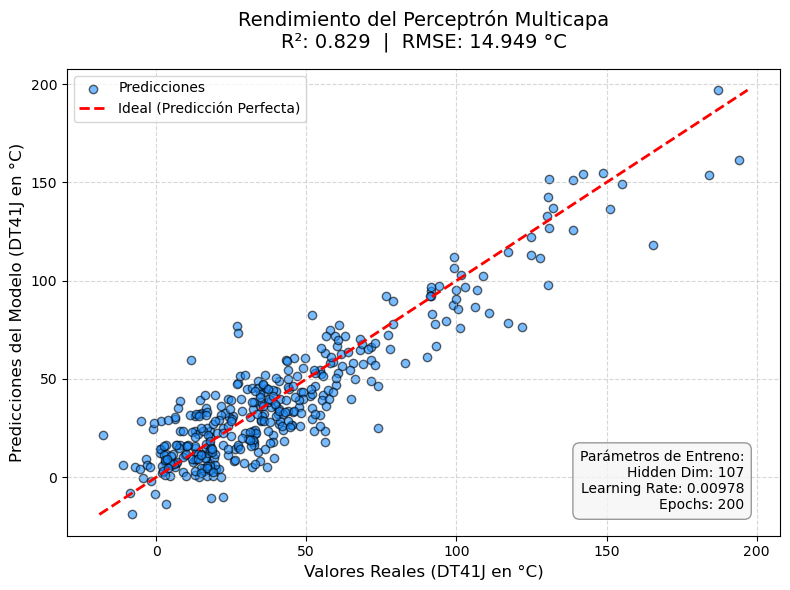

In [22]:
# Creamos la figura
plt.figure(figsize=(8, 6))

# Dibujamos los puntos (Valores reales vs Predicciones)
plt.scatter(y_test_real, preds_real, alpha=0.6, color='dodgerblue', 
            edgecolor='k', label='Predicciones')

# Calculamos los límites para dibujar la línea diagonal ideal (y = x)
min_val = min(y_test_real.min(), preds_real.min())
max_val = max(y_test_real.max(), preds_real.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', 
         linewidth=2, label='Ideal (Predicción Perfecta)')

# Añadimos el título con las métricas RMSE y R²

plt.title(f"Rendimiento del Perceptrón Multicapa\nR²: {r2_real:.3f}  |  RMSE: {rmse_real:.3f} °C", 
          fontsize=14, pad=15)

# Etiquetas de los ejes
plt.xlabel("Valores Reales (DT41J en °C)", fontsize=12)
plt.ylabel("Predicciones del Modelo (DT41J en °C)", fontsize=12)

# Preparamos el texto a mostrar
texto_params = (
    "Parámetros de Entreno:\n"
    f"Hidden Dim: {best_hidden_dim}\n"
    f"Learning Rate: {best_lr:.5f}\n"
    f"Epochs: {epochs}"
)

# Definimos el estilo de la caja (fondo blanco humo, bordes redondeados, algo de transparencia)
estilo_caja = dict(boxstyle='round,pad=0.5', facecolor='whitesmoke', edgecolor='gray', alpha=0.8)

# Colocamos el texto en la esquina inferior derecha 
# (x=0.95, y=0.05 son posiciones relativas de 0 a 1 dentro del gráfico)
plt.gca().text(0.95, 0.05, texto_params, transform=plt.gca().transAxes, 
               fontsize=10, verticalalignment='bottom', horizontalalignment='right', 
               bbox=estilo_caja)

# Añadimos la leyenda y una cuadrícula para facilitar la lectura
plt.legend(loc='best')
plt.grid(True, linestyle='--', alpha=0.5)

# Ajustamos el layout y mostramos el gráfico
plt.tight_layout()
plt.savefig("../data/img/02_perceptron_inicial.png", dpi=300)
plt.show()